     Supplier       Site  Deliveries  Deliveries on time  Purchase value  \
0      Nestle  Amsterdam          22                  21           23078   
1      Nestle  Amsterdam          22                  22           22550   
2      Nestle  Amsterdam          24                  22           30456   
3      Nestle  Amsterdam          25                  24           26600   
4      Nestle  Amsterdam          26                  26           34190   
..        ...        ...         ...                 ...             ...   
115  Unilever    Utrecht          20                  20           19940   
116  Unilever    Utrecht          21                  20           21000   
117  Unilever    Utrecht          22                  20           23276   
118  Unilever    Utrecht          22                  22           24178   
119  Unilever    Utrecht          23                  21           26680   

        Month  Year  
0        June  2023  
1    February  2023  
2     January  2023  

/tmp/ipykernel_4579/826489662.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))


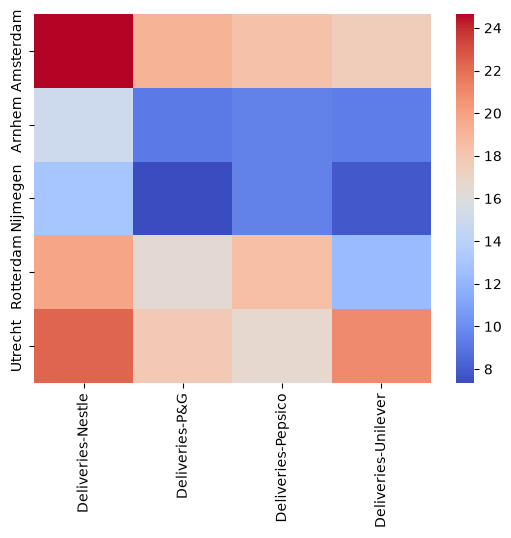

            Purchase value
Year-Month                
2023-01           18066.65
2023-02           16383.15
2023-03           16508.35
2023-04           16815.20
2023-05           16458.10
2023-06           18025.60


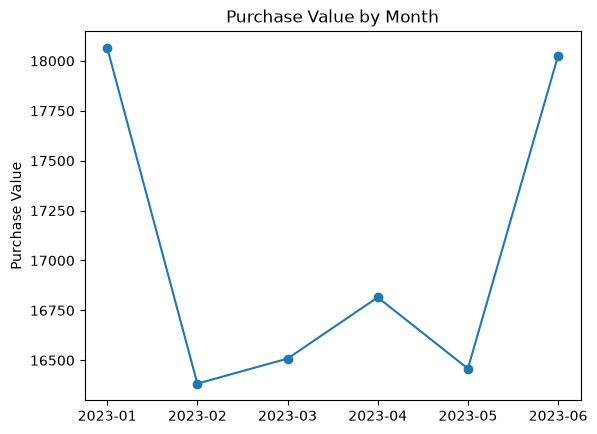

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Jun 12 12:27:11 2023

@author: jbrweelden
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import data and adjust formatting

df = pd.read_csv('Week 2.csv')
print(df)

# Combine 'Month' and 'Year' columns into a single 'Date' column
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str))

# Format the 'Date' column to display only year and month
df['Year-Month'] = df['Date'].dt.strftime('%Y-%m')

# Delete the "date" colummn
df = df.drop('Date', axis=1)

#############################################

# Create a Pivot table to summarize amount of deliveries per site

# Summarize data using Pivot by Site
pivot_df = df.pivot_table(index='Site', columns='Supplier', values=['Deliveries'], aggfunc='mean') 

# Print the pivoted DataFrame
print("\nPivoted DataFrame:")
print(pivot_df)

#############################################

# Create a heatmap
sns.heatmap(pivot_df, cmap='coolwarm')

# remove labels
plt.xlabel('')
plt.ylabel('')

# Show the plot
plt.show()

#############################################

# Create line chart based on pivoted DataFrame

pivot_df2 = df.pivot_table(index='Year-Month', 
                           values=['Purchase value'], 
                           aggfunc='mean',
                           )
print(pivot_df2)

# Reset the index to convert the 'Year-Month' column into a regular column
pivot_df2 = pivot_df2.reset_index()

# Create a line chart
plt.plot(pivot_df2['Year-Month'], pivot_df2['Purchase value'], marker='o')

# Set the title for the line chart
plt.title('Purchase Value by Month')

# Set the y-axis label
plt.ylabel('Purchase Value')

# Show the line chart
plt.show()